In [1]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
import matplotlib.pyplot as plt
from scippneutron.conversion.graph.beamline import beamline
import numpy as np

import os
import sys 



module_source = os.path.dirname(os.path.dirname(os.getcwd()))


sys.path.append(module_source)
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object


cspec_source_samp = {'source_name': "ESS_Source", 
                     'sample_name': "Sample"}

let_source_samp = {'source_name': "SourceMantid", 
                     'sample_name': "iso_samp"}

In [2]:
exp_folder = "CSPEC_vanad_3"
file_path = os.path.join(module_source, "runs", exp_folder)

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp(**cspec_source_samp)

    
data = ms.load_data(file_path)

for mon in data:
    mon.set_title(mon.name)

lambda_tom = ms.name_search('Cheat_lambda_tof_monitor',data)

event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object['events'].bins.coords["tof"] = event_object['events'].bins.coords["t"] #+ sc.scalar(2.86e-3/2, unit = 's')
# Add additional information required for inelastic scattering
event_object

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 21752}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

Skipped plotting Banana_1 as it contains event data.


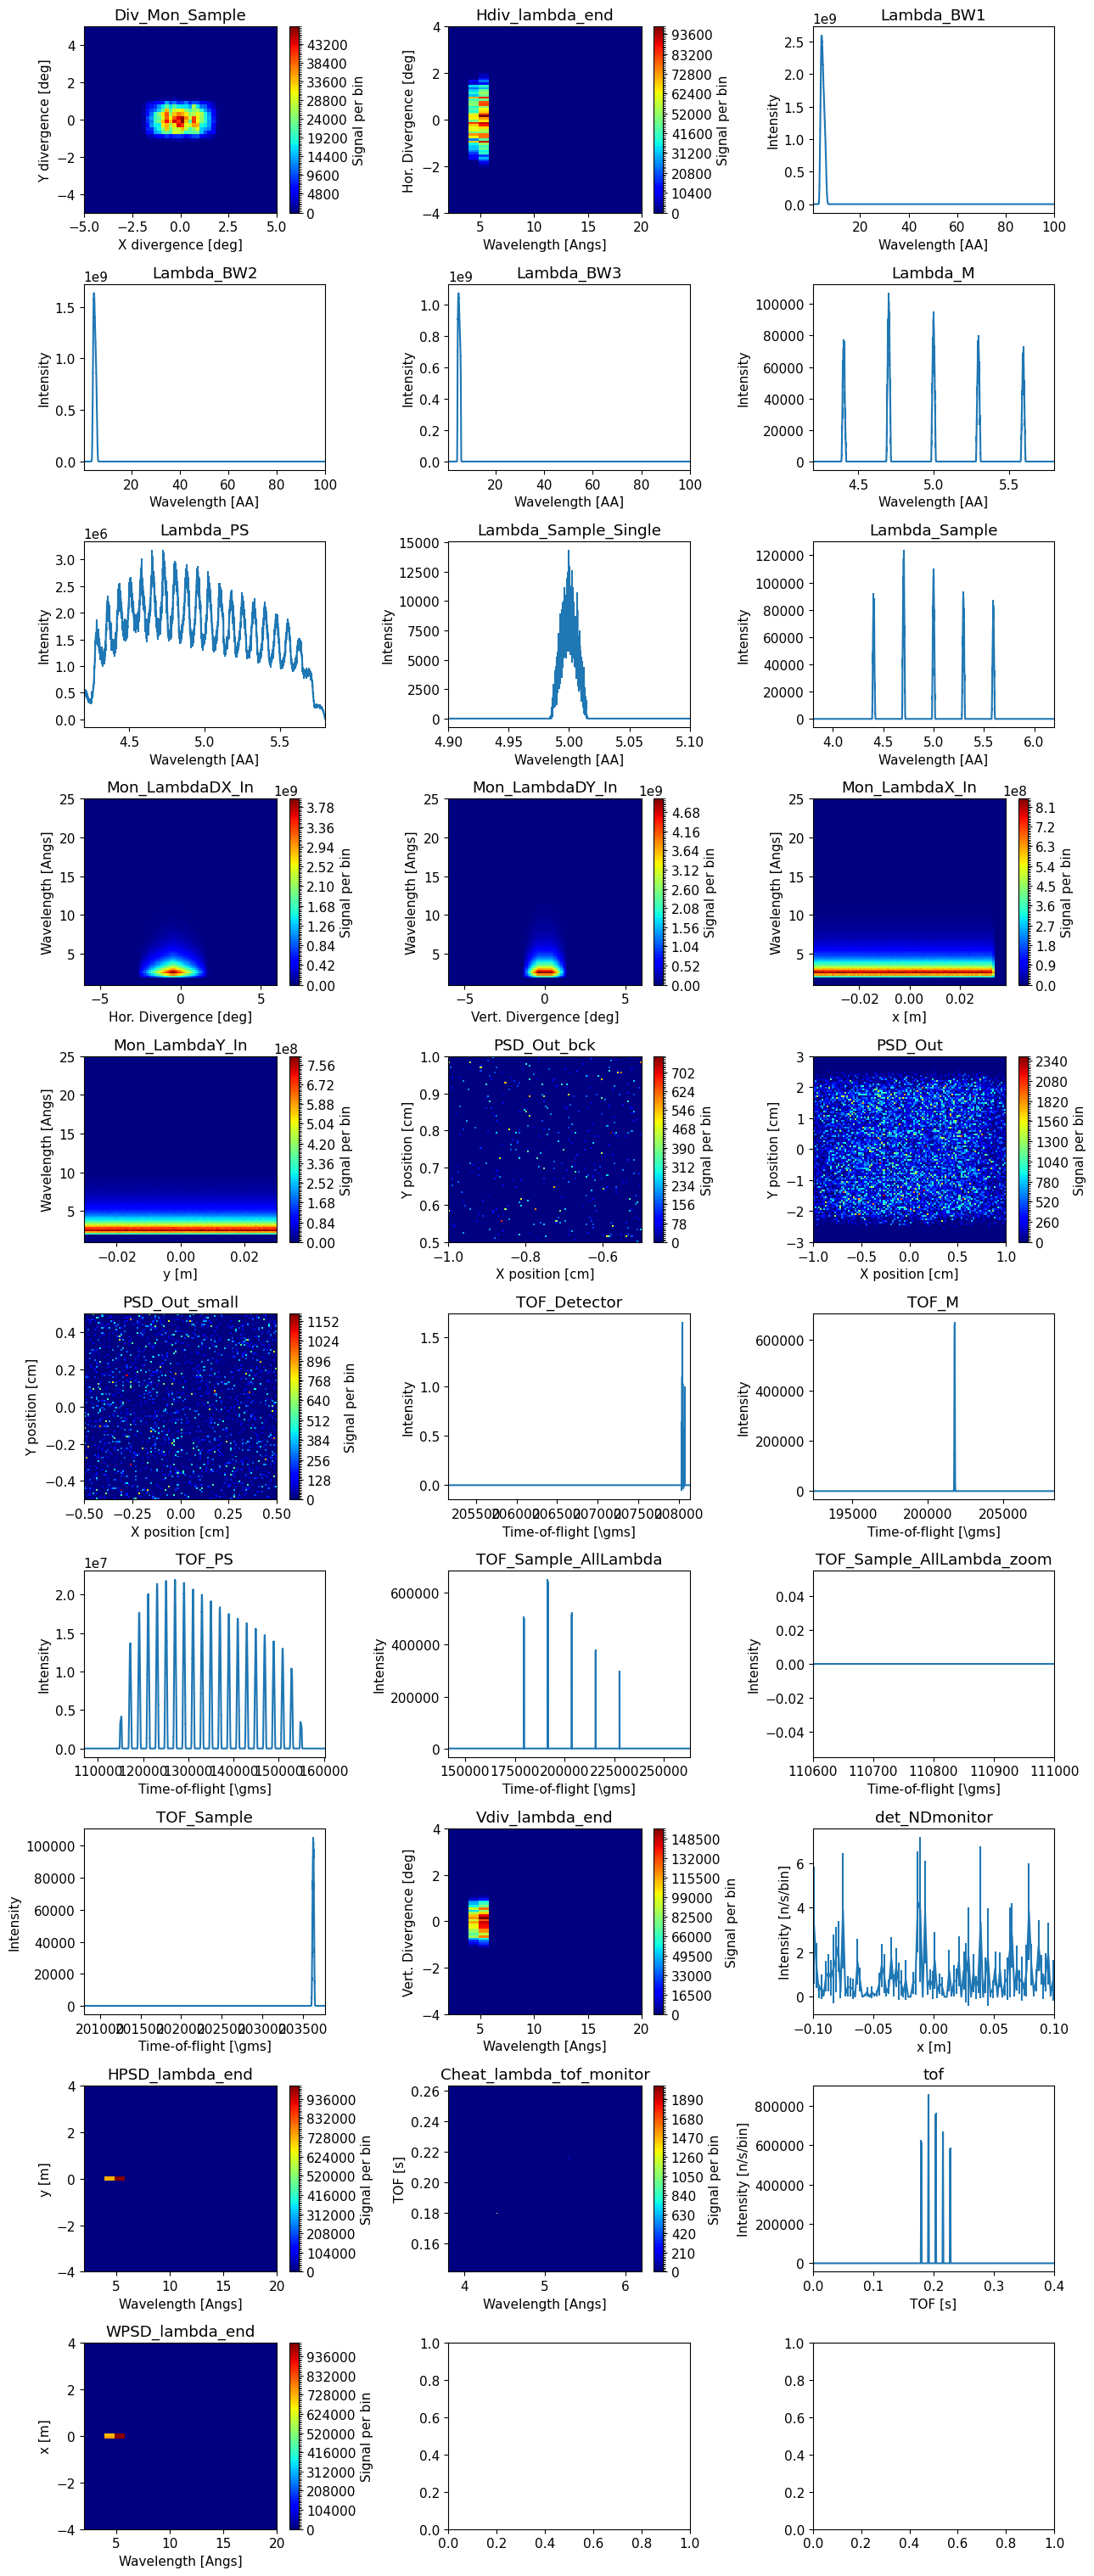

In [3]:
ms.make_sub_plot(data)

In [4]:
# lambda_tom = ms.name_search('Cheat_lambda_tof_monitor',data)

# event_object['events'] = produce_trex_event_object(event_object['events'], lambda_tom)

event_object['events'] = produce_trex_event_object(event_object['events'], file_path, "TOF_Sample_AllLambda")

In [5]:

from scippneutron.conversion.graph.beamline import beamline

In [6]:
qens_graph = {**beamline(scatter=True), **inelastic}

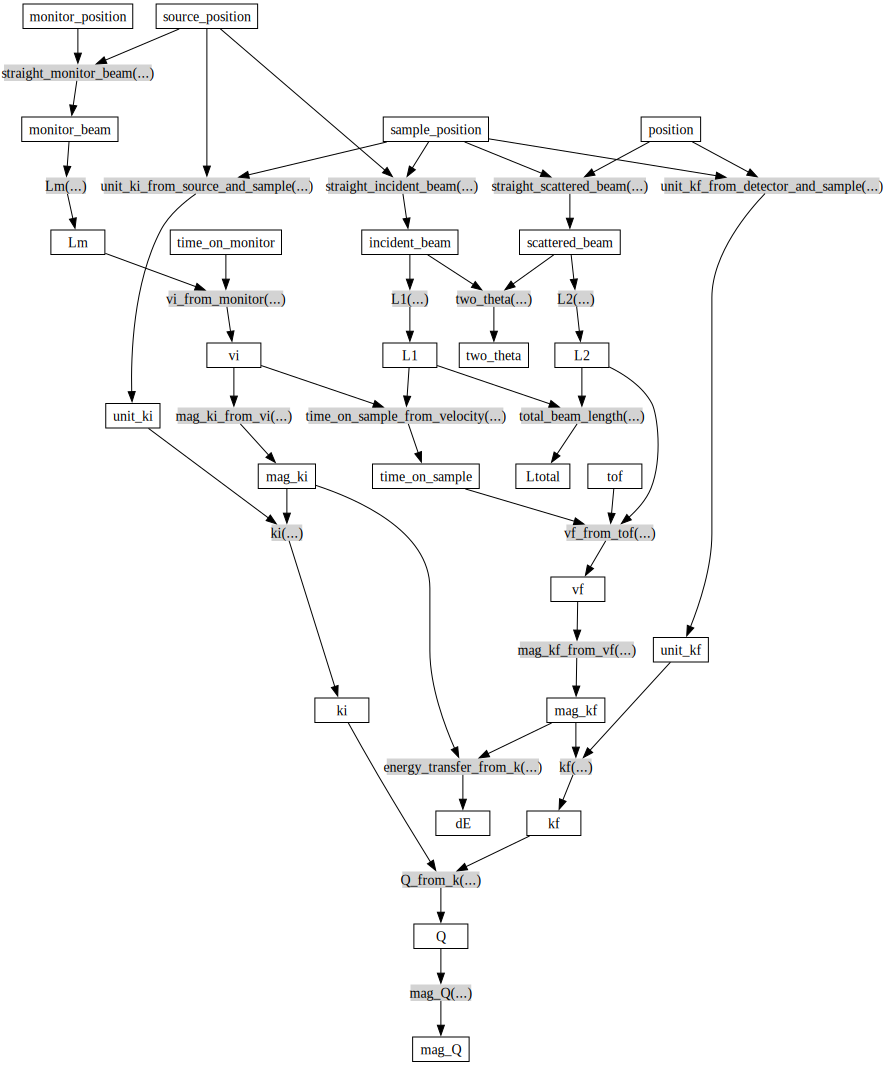

In [7]:
sc.show_graph(qens_graph)


In [8]:
event_object['events'] = event_object['events'].transform_coords("dE", graph=qens_graph)
event_object['events'] = event_object['events'].transform_coords("mag_Q", graph=qens_graph)

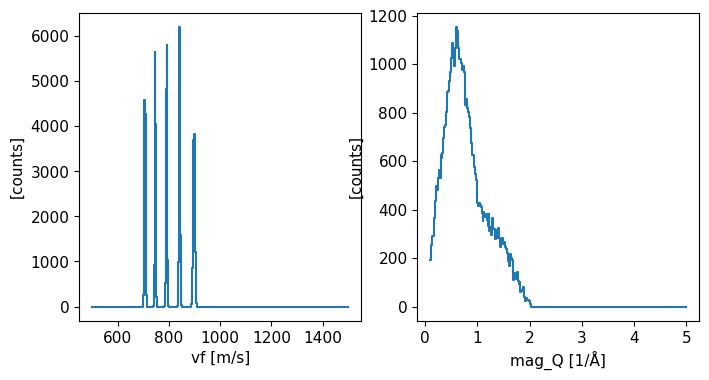

In [9]:
fig, ax = plt.subplots(1,2, figsize= (8,4))


# Apply mask to the binned variable
vf_range = sc.array(values=np.linspace(500,1500,300),unit = 'm/s', dims=['vf'])
event_object['events'].bin(vf=vf_range).sum('pixel_id').plot(ax=ax[0], linestyle='-', color='tab:blue')
# ax.set_xlim(0,2000)

# mask = event_object.coords['vf'] < sc.scalar(5000, unit=event_object.coords['vf'].unit)
Q_range = sc.array(values=np.linspace(0.1,5,300),unit = '1/Angstrom', dims=['mag_Q'])
event_object['events'].bin(mag_Q=Q_range).sum('pixel_id').plot(ax=ax[1], linestyle='-', color='tab:blue')

plt.show()

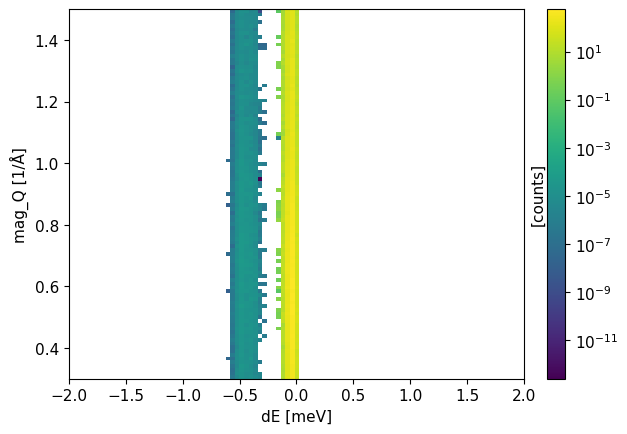

In [10]:
fig,ax = plt.subplots()

# event_object['events'].bins.masks['dE_cut'] = event_object['events'].bins.coords['dE'] < sc.scalar(-10, unit=event_object['events'].bins.coords['dE'].unit)

#mask = event_object['events'].bins.coords['time_on_monitor'] != sc.scalar(time_centroids.values[3], unit=event_object['events'].bins.coords['time_on_monitor'].unit)

#< sc.scalar(0.15, unit=event_object['events'].bins.coords['time_on_monitor'].unit)

Q_range = sc.array(values=np.linspace(0.3,1.5,100),unit = '1/Angstrom', dims=['mag_Q'])
dE_range = sc.array(values=np.linspace(-2,2,100),unit = 'meV', dims=['dE'])
event_object['events'].bin(mag_Q = Q_range, dE=dE_range).sum('pixel_id').plot(ax=ax, norm = 'log')
# ax.set_xlim(-5,5)
# ax.set_ylim(2.5,5)
plt.show()

In [11]:
event_object['events']

<scipp.DataArray>
Dimensions: Sizes[pixel_id:21752, ]
Coordinates:
  L1                        float64              [m]  ()  159.954
  L2                        float64              [m]  (pixel_id)  [4.02385, 4.02385, ..., 4.02385, 4.02385]
  Lm                        float64              [m]  ()  159.954
  incident_beam             vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_beam              vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 29993, 29994]
  position                  vector3              [m]  (pixel_id)  [(-1.83975, -2.4318, 162.66), (-1.80103, -2.4318, 162.692), ..., (3.87755, 1.53937, 159.992), (3.87775, 1.53937, 159.942)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  scattered_beam            vector3              [m]  (pixel_id)  [(-2.21772, -1.98552, 2.70755), (-2.179, -1.98551, 2.73881), ..., (3.49958, 1.98565, 0.0387978), (3.49978, 1.98565, -0.0109551)]
  source_position           vector3              [m]  ()  (0, 0, 0)
  unit_kf                   vector3  [dimensionless]  (pixel_id)  [(-0.551142, -0.493437, 0.672876), (-0.541522, -0.493436, 0.680643), ..., (0.869709, 0.493471, 0.00964196), (0.869758, 0.493471, -0.00272253)]
  unit_ki                   vector3  [dimensionless]  ()  (0.00236299, -0.0027901, 0.999993)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 329742),
          data=float64[counts],
          coords={'t':float64[s], 'tof':float64[s], 'time_on_monitor':float64[s],
                  'vi':float64[m/s], 'mag_ki':float64[1/Å], 'time_on_sample':float64[s],
                  'vf':float64[m/s], 'mag_kf':float64[1/Å], 'dE':float64[meV],
                  'kf':vector3[1/Å], 'ki':vector3[1/Å], 'Q':vector3[1/Å],
                  'mag_Q':float64[1/Å]})

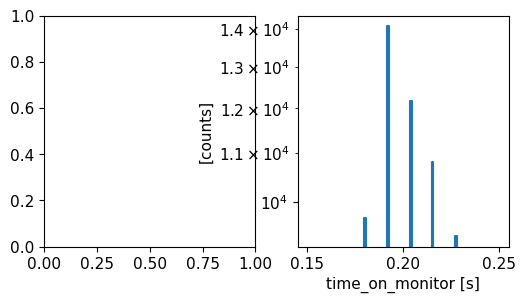

In [12]:
fig,ax = plt.subplots(1,2, figsize = (6,3))

# lam_range = sc.array(values=np.linspace(3,7,100),unit = 'Angstrom', dims=['lambda_i'])
# event_object['events'].bin(lambda_i = lam_range).sum('pixel_id').plot(ax=ax[0], norm = 'log')

tom_range = sc.array(values=np.linspace(0.15,0.25,100),unit = 's', dims=['time_on_monitor'])
event_object['events'].bin(time_on_monitor = tom_range).sum('pixel_id').plot(ax=ax[1], norm = 'log')

plt.show()

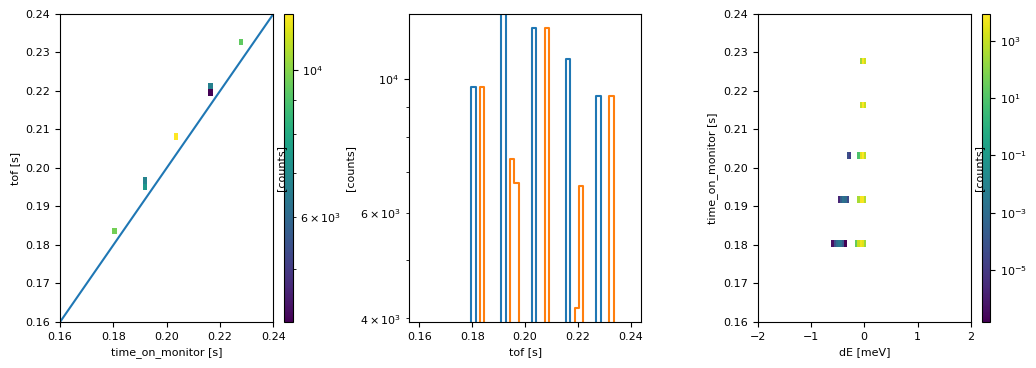

In [19]:

plt.rc('font', size=8)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
tof_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['tof'])
tom_range = sc.array(values=np.linspace(0.16, 0.24, 50), unit='s', dims=['time_on_monitor'])
lamda_range = sc.array(values=np.linspace(4, 6, 50), unit='Angstrom', dims=['lambda_i'])

event_object['events'].bin(tof=tof_range, time_on_monitor=tom_range).sum('pixel_id').plot(ax=ax[0], norm='log')


# tof_range = sc.array(values=np.linspace(0.16, 0.24, 300), unit='s', dims=['tof'])
# tom_range = sc.array(values=np.linspace(0.16, 0.24, 300), unit='s', dims=['time_on_monitor'])

event_object['events'].bin(time_on_monitor=tom_range).sum('pixel_id').plot(ax=ax[1])
event_object['events'].bin(tof=tof_range).sum('pixel_id').plot(ax=ax[1], color='tab:orange', norm = 'log')


ax[0].plot(tom_range.values,tof_range.values)
# event_object['events'].bin(time_on_monitor=tom_range, lambda_i=lamda_range).sum('pixel_id').plot(norm='log', ax=ax[2])

dE_range = sc.array(values=np.linspace(-2,2,100),unit = 'meV', dims=['dE'])
# lamda_range = sc.array(values=np.linspace(4,6,100),unit = 'Angstrom', dims=['lambda_i'])
event_object['events'].bin(time_on_monitor = tom_range,dE = dE_range).sum('pixel_id').plot(norm = 'log', ax = ax[2])

# Increase horizontal space between subplots to give colorbars room
fig.subplots_adjust(wspace=0.5)


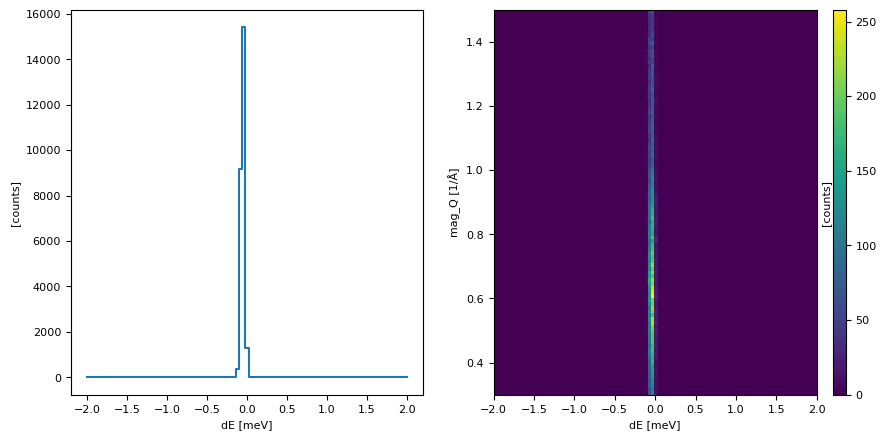

In [15]:
fig, ax = plt.subplots(1,2,figsize=(10,5))



masked = event_object['events'].copy()
target_tom = sc.scalar(0.2, unit='s')
tol = sc.scalar(0.01, unit='s')

mask = abs(masked.bins.coords['time_on_monitor'] - target_tom) > tol
masked.bins.masks['tom'] = mask
masked.hist(dE=dE_range).sum('pixel_id').plot(linestyle='-', color='tab:blue', ax=ax[0])

masked.bin(mag_Q = Q_range, dE=dE_range).sum('pixel_id').plot(ax=ax[1])
plt.show()


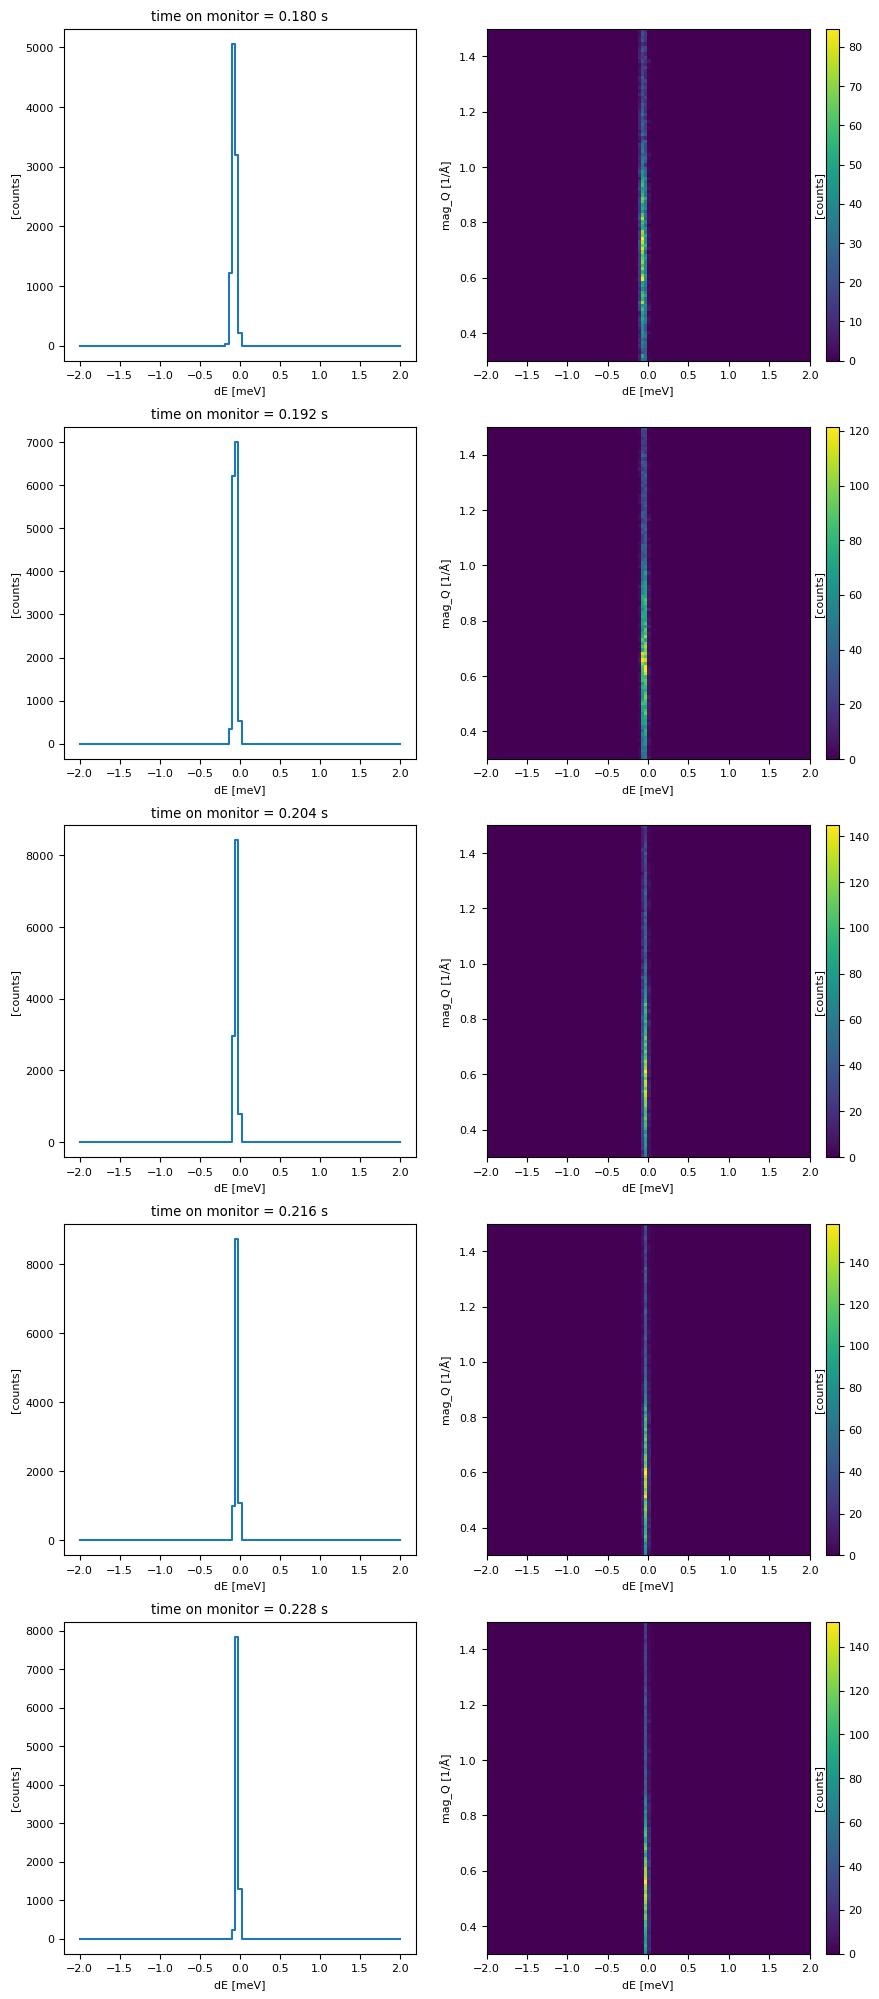

In [ ]:
toms = np.unique(event_object['events'].bins.coords['time_on_monitor'].values[0].values)

fig, ax = plt.subplots(1*len(toms),2,figsize=(10,5*len(toms)))

for i, tom in enumerate(toms):

    mask = masked.bins.coords['time_on_monitor'] != sc.scalar(tom, unit='s')
    masked = event_object['events'].copy()
    masked.bins.masks['tom'] = mask
    masked.hist(dE=dE_range).sum('pixel_id').plot(linestyle='-', color='tab:blue', ax=ax[i, 0])
    masked.bin(mag_Q = Q_range, dE=dE_range).sum('pixel_id').plot(ax=ax[i, 1])
    ax[i, 0].set_title(f"time on monitor = {tom:.3f} s")



plt.show()